In [1]:
import os
import stark as sk
import numpy as np
import pandas as pd


In [2]:
hdata = sk.HData.read_h5ad('/Users/ckw/warehouse/metacell/stark/cycle_h5ad/cycle.h5ad')

In [3]:
hdata.metacells

,CellType,CellType_purity,cell_num,w_min,w_max,P_adj,EP_v2,total_depth,cell_count,mean_depth,dominant_label
Metacell,,,,,,,,,,,
1,early-S,0.937500,48,0.855662,1.0,0.921875,0.788814,11377160,48,237024.166667,early-S
2,post-M,0.750000,20,0.776393,1.0,0.687500,0.533770,8727838,20,436391.900000,post-M
3,late-S-G2,0.581395,43,0.847501,1.0,0.476744,0.404041,14229493,43,330918.441860,late-S-G2
4,late-S-G2,0.897959,49,0.857143,1.0,0.872449,0.747813,19213383,49,392109.857143,late-S-G2
5,early-S,0.905660,53,0.862639,1.0,0.882075,0.760913,16200611,53,305671.905660,early-S
6,G1,0.924528,53,0.862639,1.0,0.905660,0.781258,13157654,53,248257.622642,G1
7,late-S-G2,0.911765,34,0.828501,1.0,0.889706,0.737123,11896559,34,349898.794118,late-S-G2
8,late-S-G2,0.920000,50,0.858579,1.0,0.900000,0.772721,17740185,50,354803.700000,late-S-G2
9,early-S,1.000000,41,0.843826,1.0,1.000000,0.843826,12195055,41,297440.365854,early-S


In [ ]:
sk.tl.aggregate_metacell_mat(hdata, force_aggregate=False)


Aggregating @ 500000: 100%|██████████| 30/30 [00:03<00:00,  9.35it/s]


✅ 全量聚合完成！
   可通过 base_on='mat' 方式可视化的分辨率: [50000, 500000, 1000000]
   调用示例: sk.pl.plot_metacell_heatmap(hdata, ..., resolution=50000, base_on='mat')


['G1', 'early-S', 'late-S-G2']
[6, 10, 16, 21]
['G1', 'early-S', 'late-S-G2']
['4', '19', '20', '42', '49', '51', '57', '61', '81', '86', '88', '98', '100', '101', '103', '104', '114', '117', '124', '137', '145', '189', '212', '214', '216', '363', '364', '404', '525', '533', '537', '540', '557', '559', '562', '565', '570', '573', '576', '580', '581', '587', '613', '616', '618', '624', '637', '643', '648', '661', '664', '665', '668', '670', '671', '673', '676', '681', '683', '684', '686', '687', '698', '701', '704', '705', '710', '718', '721', '722', '725', '730', '731', '734', '735', '739', '740', '743', '745', '746', '752', '755', '756', '757', '781', '783', '785', '793', '795', '797', '799', '804', '808', '810', '812', '815', '816', '818', '819', '822', '823', '824', '825', '826', '828', '830', '833', '836', '838', '842', '843', '849', '852', '855', '865', '870', '872', '875', '879', '880', '881', '882', '883', '885', '886', '887', '888', '889', '891', '892', '893', '894', '895', '89

Calculating SCC: 100%|██████████| 1225/1225 [00:05<00:00, 207.48it/s]


计算 Metacell 两两之间的分层相关性 (SCC)...


Calculating SCC: 100%|██████████| 6/6 [00:00<00:00, 181.11it/s]
/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_23903/1738546775.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Type', y='Correlation', data=df, palette=palette,



T-test results: t-statistic = -39.1014, p-value = 5.9858e-218
Single Cell 平均 SCC: 0.0920
Metacell 平均 SCC: 0.8080


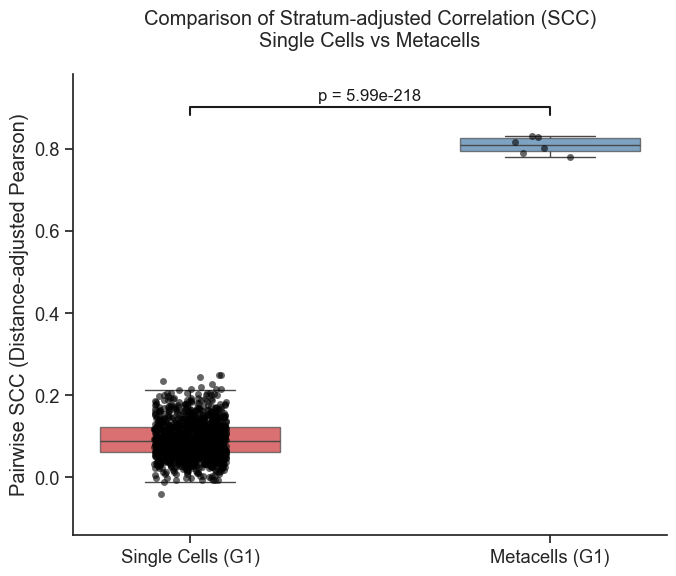


分析完成！


In [ ]:
# =========================================================================
# 验证 Metacell 优势：单细胞 vs Metacell 距离分层相关性 (Stratum Correlation)
# =========================================================================
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

# 忽略除以 0 或全 0 向量计算皮尔逊相关性时产生的 warning
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================================
# 1. 核心计算函数：计算两个稀疏矩阵之间的距离分层相关性 (类似 HiCRep 核心逻辑)
# =========================================================================
def calc_stratum_cor(mat1, mat2, max_dist=50):
    """
    计算两个 Hi-C 矩阵的 Stratum-adjusted Correlation (SCC 简易版)
    
    参数:
    mat1 (scipy.sparse.csr_matrix or numpy.ndarray): 矩阵1 (单个细胞或Metacell的某条染色体)
    mat2 (scipy.sparse.csr_matrix or numpy.ndarray): 矩阵2
    max_dist (int): 考虑的最大对角线距离 (bin 的个数)
    
    返回:
    float: 加权的距离分层相关系数 (SCC)
    """
    # 确保是稀疏矩阵格式提取对角线最方便
    if not isinstance(mat1, csr_matrix):
        mat1 = csr_matrix(mat1)
    if not isinstance(mat2, csr_matrix):
        mat2 = csr_matrix(mat2)
        
    cor_strata = []
    weight_strata = []
    
    # 遍历每一条对角线 (即每个一维基因组距离 d)
    # d=0 是主对角线自身，通常 Hi-C 从 d=1 或 d=2 开始计算
    for d in range(1, max_dist + 1):
        # 提取第 d 条对角线上的向量
        vec1 = mat1.diagonal(d)
        vec2 = mat2.diagonal(d)
        
        if len(vec1) <= 1:
            continue
            
        # 计算当前层的样本方差 (ddof=1)
        var1 = np.var(vec1, ddof=1)
        var2 = np.var(vec2, ddof=1)
        
        # 如果某一层的信号方差为0（比如全是0），无法计算相关性，直接跳过
        if var1 == 0 or var2 == 0:
            continue
            
        # 计算 Pearson 相关系数
        corr, _ = pearsonr(vec1, vec2)
        
        if np.isnan(corr):
            continue
            
        # 计算权重 (HiCRep 简化的权重逻辑：方差的几何平均乘以向量长度)
        # 距离越近，接触数目越多，方差通常越大，这条对角线的权重就越高
        weight = np.sqrt(var1 * var2) * len(vec1)
        
        cor_strata.append(corr)
        weight_strata.append(weight)
        
    if not weight_strata:
        return 0.0
        
    # 计算加权平均相关系数
    final_scc = np.average(cor_strata, weights=weight_strata)
    return final_scc

# =========================================================================
# 2. 批量计算两两相关性 (Pairwise Correlation)
# =========================================================================
from tqdm import tqdm
import itertools

def calc_pairwise_cor(mat_list, max_dist=50):
    cor_values = []
    # 计算总组合数用于进度条
    total_pairs = len(mat_list) * (len(mat_list) - 1) // 2 
    
    for mat_i, mat_j in tqdm(itertools.combinations(mat_list, 2), total=total_pairs, desc="Calculating SCC"):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)
    return cor_values

# =========================================================================
# 3. 模拟数据生成 (仅用于展示逻辑，真实应用中请读取你自己的稀疏矩阵)
# =========================================================================
def generate_mock_matrix(is_metacell=False, n_bins=200):
    """生成具有物理距离衰减特性的模拟 Hi-C 矩阵"""
    mat = np.zeros((n_bins, n_bins))
    
    for i in range(n_bins):
        for j in range(i, n_bins):
            dist = j - i + 1
            prob = 10 / (dist ** 1.5) # Power-law decay 距离衰减法则
            
            if is_metacell:
                # Metacell：深度较高，克服了 dropout
                val = np.random.poisson(prob * 50)
            else:
                # Single Cell：存在极高的 dropout rate (稀疏性)
                # 只有 5% 的概率能捕捉到信号
                val = np.random.poisson(prob * 5) if np.random.rand() > 0.95 else 0
                
            mat[i, j] = val
            mat[j, i] = val # 对称矩阵
            
    return csr_matrix(mat)
cell_cycle = ['G1', 'early-S', 'late-S-G2']
print(cell_cycle)
cycle_index = hdata.metacells[hdata.metacells.CellType.isin(['G1'])].index.tolist()
print(cycle_index)
sc_cell_cycle = ['G1', 'early-S', 'late-S-G2']
print(sc_cell_cycle)
sc_cycle_index = hdata.obs[hdata.obs.label.isin(['G1'])].index.tolist()
print(sc_cycle_index)
# 加上 replace=False 进行无放回抽样
sc_cycle_index = np.random.choice(sc_cycle_index, 50, replace=False)
mc_matrices  = [hdata.metacell_data['mat'][1000000][x]['chr11'] for x in cycle_index]
sc_cycle_pos = [hdata.obs.index.get_loc(x) for x in sc_cycle_index]

sc_matrices = [hdata.views_mat[1000000]['chr11'][x] for x in sc_cycle_pos]



print("计算单细胞 (Single cells) 两两之间的分层相关性 (SCC)...")
sc_cor_dist = calc_pairwise_cor(sc_matrices, max_dist=50)

print("计算 Metacell 两两之间的分层相关性 (SCC)...")
mc_cor_dist = calc_pairwise_cor(mc_matrices, max_dist=50)

# 构建 DataFrame 用于绘图和统计检验
df = pd.DataFrame({
    'Correlation': sc_cor_dist + mc_cor_dist,
    'Type': ['Single Cells (G1)'] * len(sc_cor_dist) + ['Metacells (G1)'] * len(mc_cor_dist)
})

# 独立样本 T 检验
t_stat, p_val = ttest_ind(sc_cor_dist, mc_cor_dist)
print(f"\nT-test results: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")
print(f"Single Cell 平均 SCC: {np.mean(sc_cor_dist):.4f}")
print(f"Metacell 平均 SCC: {np.mean(mc_cor_dist):.4f}")

# 绘图设置
plt.figure(figsize=(7, 6))
sns.set_theme(style="ticks", font_scale=1.2)

# 绘制箱线图 + 散点
palette = {"Single Cells (G1)": "#E41A1C", "Metacells (G1)": "#377EB8"}
ax = sns.boxplot(x='Type', y='Correlation', data=df, palette=palette, 
                    showfliers=False, width=0.5, boxprops={'alpha': 0.7})
sns.stripplot(x='Type', y='Correlation', data=df, color='black', 
                alpha=0.6, jitter=True, size=5)

# 添加 T 检验的 P value 注释
y_max = df['Correlation'].max()
y_line = y_max + 0.05
plt.plot([0, 0, 1, 1], [y_line, y_line+0.02, y_line+0.02, y_line], lw=1.5, c='k')
plt.text(0.5, y_line + 0.03, f"p = {p_val:.2e}", ha='center', va='bottom', color='k', fontsize=12)

# 调整坐标轴与标题
plt.title("Comparison of Stratum-adjusted Correlation (SCC)\nSingle Cells vs Metacells", pad=20)
plt.ylabel("Pairwise SCC (Distance-adjusted Pearson)")
plt.xlabel("")
plt.ylim(min(df['Correlation']) - 0.1, y_line + 0.1)

sns.despine()
plt.tight_layout()

# 保存图片
# plt.savefig("SCC_comparison_python.png", dpi=300)
plt.show()
print("\n分析完成！")

In [ ]:
# =========================================================================
# 验证 Metacell 优势：Single Cell vs Metacell vs Random (公平基线版 + SCI风格可视化)
# 关键修正：Random 采用“无重叠分组 + 匹配 metacell 大小 + 多次重复”
# =========================================================================
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore', category=RuntimeWarning)

RNG_SEED = 20260422
rng = np.random.default_rng(RNG_SEED)


def _to_csr(mat):
    if isinstance(mat, csr_matrix):
        return mat
    return csr_matrix(mat)


def calc_stratum_cor(mat1, mat2, max_dist=50, depth_normalize=True, use_log1p=True):
    """
    计算两个 Hi-C 矩阵的分层相关性（简化 SCC）。
    depth_normalize=True 时，按矩阵总 contact 深度做 CPM 标准化，降低测序深度偏置。
    """
    mat1 = _to_csr(mat1)
    mat2 = _to_csr(mat2)

    cor_strata = []
    weight_strata = []

    if depth_normalize:
        sum1 = float(mat1.sum())
        sum2 = float(mat2.sum())
        if sum1 <= 0 or sum2 <= 0:
            return 0.0
    else:
        sum1 = 1.0
        sum2 = 1.0

    for d in range(1, max_dist + 1):
        vec1 = mat1.diagonal(d).astype(np.float64, copy=False)
        vec2 = mat2.diagonal(d).astype(np.float64, copy=False)

        if len(vec1) <= 1:
            continue

        if depth_normalize:
            vec1 = vec1 / sum1 * 1e6
            vec2 = vec2 / sum2 * 1e6

        if use_log1p:
            vec1 = np.log1p(vec1)
            vec2 = np.log1p(vec2)

        var1 = np.var(vec1, ddof=1)
        var2 = np.var(vec2, ddof=1)
        if var1 == 0 or var2 == 0:
            continue

        corr, _ = pearsonr(vec1, vec2)
        if np.isnan(corr):
            continue

        weight = np.sqrt(var1 * var2) * len(vec1)
        cor_strata.append(corr)
        weight_strata.append(weight)

    if not weight_strata:
        return 0.0

    return float(np.average(cor_strata, weights=weight_strata))


def calc_pairwise_cor(mat_list, max_dist=50, desc="Calculating SCC"):
    cor_values = []
    total_pairs = len(mat_list) * (len(mat_list) - 1) // 2

    for mat_i, mat_j in tqdm(itertools.combinations(mat_list, 2), total=total_pairs, desc=desc):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)

    return cor_values


def _match_sizes_to_pool(sizes, pool_size):
    """将目标分组大小缩放到可用池大小，并保证每组至少 1（当 pool 足够时）。"""
    sizes = np.asarray(sizes, dtype=int)
    sizes[sizes < 1] = 1

    total = int(sizes.sum())
    if total <= pool_size:
        return sizes.tolist()

    scaled = np.floor(sizes / total * pool_size).astype(int)
    scaled[scaled < 1] = 1

    while scaled.sum() > pool_size:
        idx = np.argmax(scaled)
        if scaled[idx] > 1:
            scaled[idx] -= 1
        else:
            break

    while scaled.sum() < pool_size:
        idx = np.argmin(scaled)
        scaled[idx] += 1

    return scaled.tolist()


def build_random_pseudometacells(sc_pool_indices, group_sizes, matrix_accessor, rng_obj):
    """
    用无重叠分组构建随机伪 metacell，避免同一 cell 在多个 random metacell 里重复出现。
    """
    if len(sc_pool_indices) == 0:
        return []

    group_sizes = _match_sizes_to_pool(group_sizes, len(sc_pool_indices))
    shuffled = rng_obj.permutation(sc_pool_indices)

    random_mats = []
    start = 0
    for gsz in group_sizes:
        end = start + gsz
        grp = shuffled[start:end]
        if len(grp) == 0:
            continue

        mats = [matrix_accessor[idx] for idx in grp]
        agg = mats[0].copy()
        for m in mats[1:]:
            agg = agg + m
        random_mats.append(agg)
        start = end

        if start >= len(shuffled):
            break

    return random_mats


def p_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_sig_bar(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=11)


cell_cycles = ['G1', 'early-S', 'late-S-G2']
n_random_trials = 20
all_results = []
summary_rows = []

for cycle in cell_cycles:
    print(f"\n[{cycle}] 开始处理...")

    mc_ids = hdata.metacells[hdata.metacells.CellType.isin([cycle])].index.tolist()
    mc_matrices = [hdata.metacell_data['mat'][1000000][mc_id]['chr11'] for mc_id in mc_ids]

    sc_pool = hdata.obs[hdata.obs.label.isin([cycle])].index.tolist()
    if len(sc_pool) < 2 or len(mc_matrices) < 2:
        print(f"[{cycle}] 样本不足，跳过")
        continue

    n_sc_samples = min(50, len(sc_pool))
    sc_sampled_index = rng.choice(sc_pool, n_sc_samples, replace=False)
    sc_pos = [hdata.obs.index.get_loc(x) for x in sc_sampled_index]
    sc_matrices = [hdata.views_mat[1000000]['chr11'][p] for p in sc_pos]

    if 'metacell' in hdata.obs.columns:
        cycle_obs = hdata.obs[hdata.obs.label.isin([cycle])]
        group_sizes = [(cycle_obs['metacell'] == mc_id).sum() for mc_id in mc_ids]
    else:
        fallback_size = max(2, len(sc_pool) // max(2, len(mc_ids)))
        group_sizes = [fallback_size] * len(mc_ids)

    group_sizes = [int(max(1, s)) for s in group_sizes]

    sc_cor_dist = calc_pairwise_cor(sc_matrices, max_dist=50, desc=f"SC SCC ({cycle})")
    mc_cor_dist = calc_pairwise_cor(mc_matrices, max_dist=50, desc=f"MC SCC ({cycle})")

    random_trial_means = []
    random_trial_distributions = []

    sc_pool_pos = [hdata.obs.index.get_loc(x) for x in sc_pool]
    matrix_accessor = hdata.views_mat[1000000]['chr11']

    for t in range(n_random_trials):
        random_matrices = build_random_pseudometacells(
            sc_pool_pos,
            group_sizes,
            matrix_accessor,
            rng,
        )

        if len(random_matrices) < 2:
            continue

        rand_cor_dist = calc_pairwise_cor(
            random_matrices,
            max_dist=50,
            desc=f"Random SCC ({cycle}) trial={t+1}",
        )
        random_trial_distributions.append(rand_cor_dist)
        random_trial_means.append(float(np.mean(rand_cor_dist)))

    for val in mc_cor_dist:
        all_results.append({'Correlation': val, 'Type': 'Metacell', 'CellCycle': cycle})
    if random_trial_distributions:
        for val in random_trial_distributions[0]:
            all_results.append({'Correlation': val, 'Type': 'Random Metacell', 'CellCycle': cycle})
    for val in sc_cor_dist:
        all_results.append({'Correlation': val, 'Type': 'Single Cell', 'CellCycle': cycle})

    mc_mean = float(np.mean(mc_cor_dist)) if len(mc_cor_dist) else np.nan
    rand_mean = float(np.mean(random_trial_means)) if len(random_trial_means) else np.nan
    beat_rate = float(np.mean(np.asarray(random_trial_means) >= mc_mean)) if len(random_trial_means) else np.nan

    summary_rows.append({
        'CellCycle': cycle,
        'SC_mean': float(np.mean(sc_cor_dist)) if len(sc_cor_dist) else np.nan,
        'MC_mean': mc_mean,
        'Random_mean_over_trials': rand_mean,
        'Random_beats_MC_rate': beat_rate,
        'Random_trials': len(random_trial_means),
    })


df = pd.DataFrame(all_results)
summary_df = pd.DataFrame(summary_rows)

print("\n--- 公平基线统计（关键看 Random_beats_MC_rate）---")
print(summary_df)

# ===================== SCI风格绘图 + 组内假设检验 =====================
sns.set_theme(
    style="white",
    context="paper",
    rc={
        "axes.linewidth": 1.2,
        "font.size": 11,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    },
)

type_order = ["Metacell", "Random Metacell", "Single Cell"]
cycle_order = ['G1', 'early-S', 'late-S-G2']
palette = {
    "Metacell": "#2C7FB8",
    "Random Metacell": "#7FCDBB",
    "Single Cell": "#F03B20",
}



[G1] 开始处理...


Random SCC (G1) trial=20: 100%|██████████| 6/6 [00:00<00:00, 178.54it/s]



[early-S] 开始处理...


Random SCC (early-S) trial=20: 100%|██████████| 66/66 [00:00<00:00, 181.64it/s]



[late-S-G2] 开始处理...


Random SCC (late-S-G2) trial=20: 100%|██████████| 66/66 [00:00<00:00, 188.67it/s]


--- 公平基线统计（关键看 Random_beats_MC_rate）---
   CellCycle   SC_mean   MC_mean  Random_mean_over_trials  \
0         G1  0.040833  0.691798                 0.672671   
1    early-S  0.069904  0.625599                 0.568678   
2  late-S-G2  0.068238  0.507223                 0.479997   

   Random_beats_MC_rate  Random_trials  
0                   0.0             20  
1                   0.0             20  
2                   0.0             20  


In [ ]:
def calc_pairwise_cor_diagnostics(mat_list, max_dist=50):
    cor_values = []
    suspicious_pairs = []
    
    # 将 mat_list 转换为带有索引的枚举，方便追踪是哪两个矩阵
    for (i, mat_i), (j, mat_j) in itertools.combinations(enumerate(mat_list), 2):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)
        
        # 如果相关性异常高，记录下来
        if scc > 0.95:
            suspicious_pairs.append((i, j, scc))
            
    if suspicious_pairs:
        print("\n⚠️ 警告：发现异常高的相关性 (>0.95)！")
        for p in suspicious_pairs[:5]: # 只打印前 5 个
            print(f"矩阵索引: {p[0]} vs {p[1]}, SCC: {p[2]:.4f}")
            
    return cor_values

In [ ]:
# calc_pairwise_cor_diagnostics(sc_matrices)


--- 组内显著性检验（Mann-Whitney U）---
   CellCycle          Comparison             p Stars
0         G1  Metacell vs Random  4.848485e-01    ns
1         G1  Metacell vs Single  4.189036e-16  ****
2    early-S  Metacell vs Random  4.208853e-08  ****
3    early-S  Metacell vs Single  9.962589e-43  ****
4  late-S-G2  Metacell vs Random  2.444406e-06  ****
5  late-S-G2  Metacell vs Single  9.962589e-43  ****


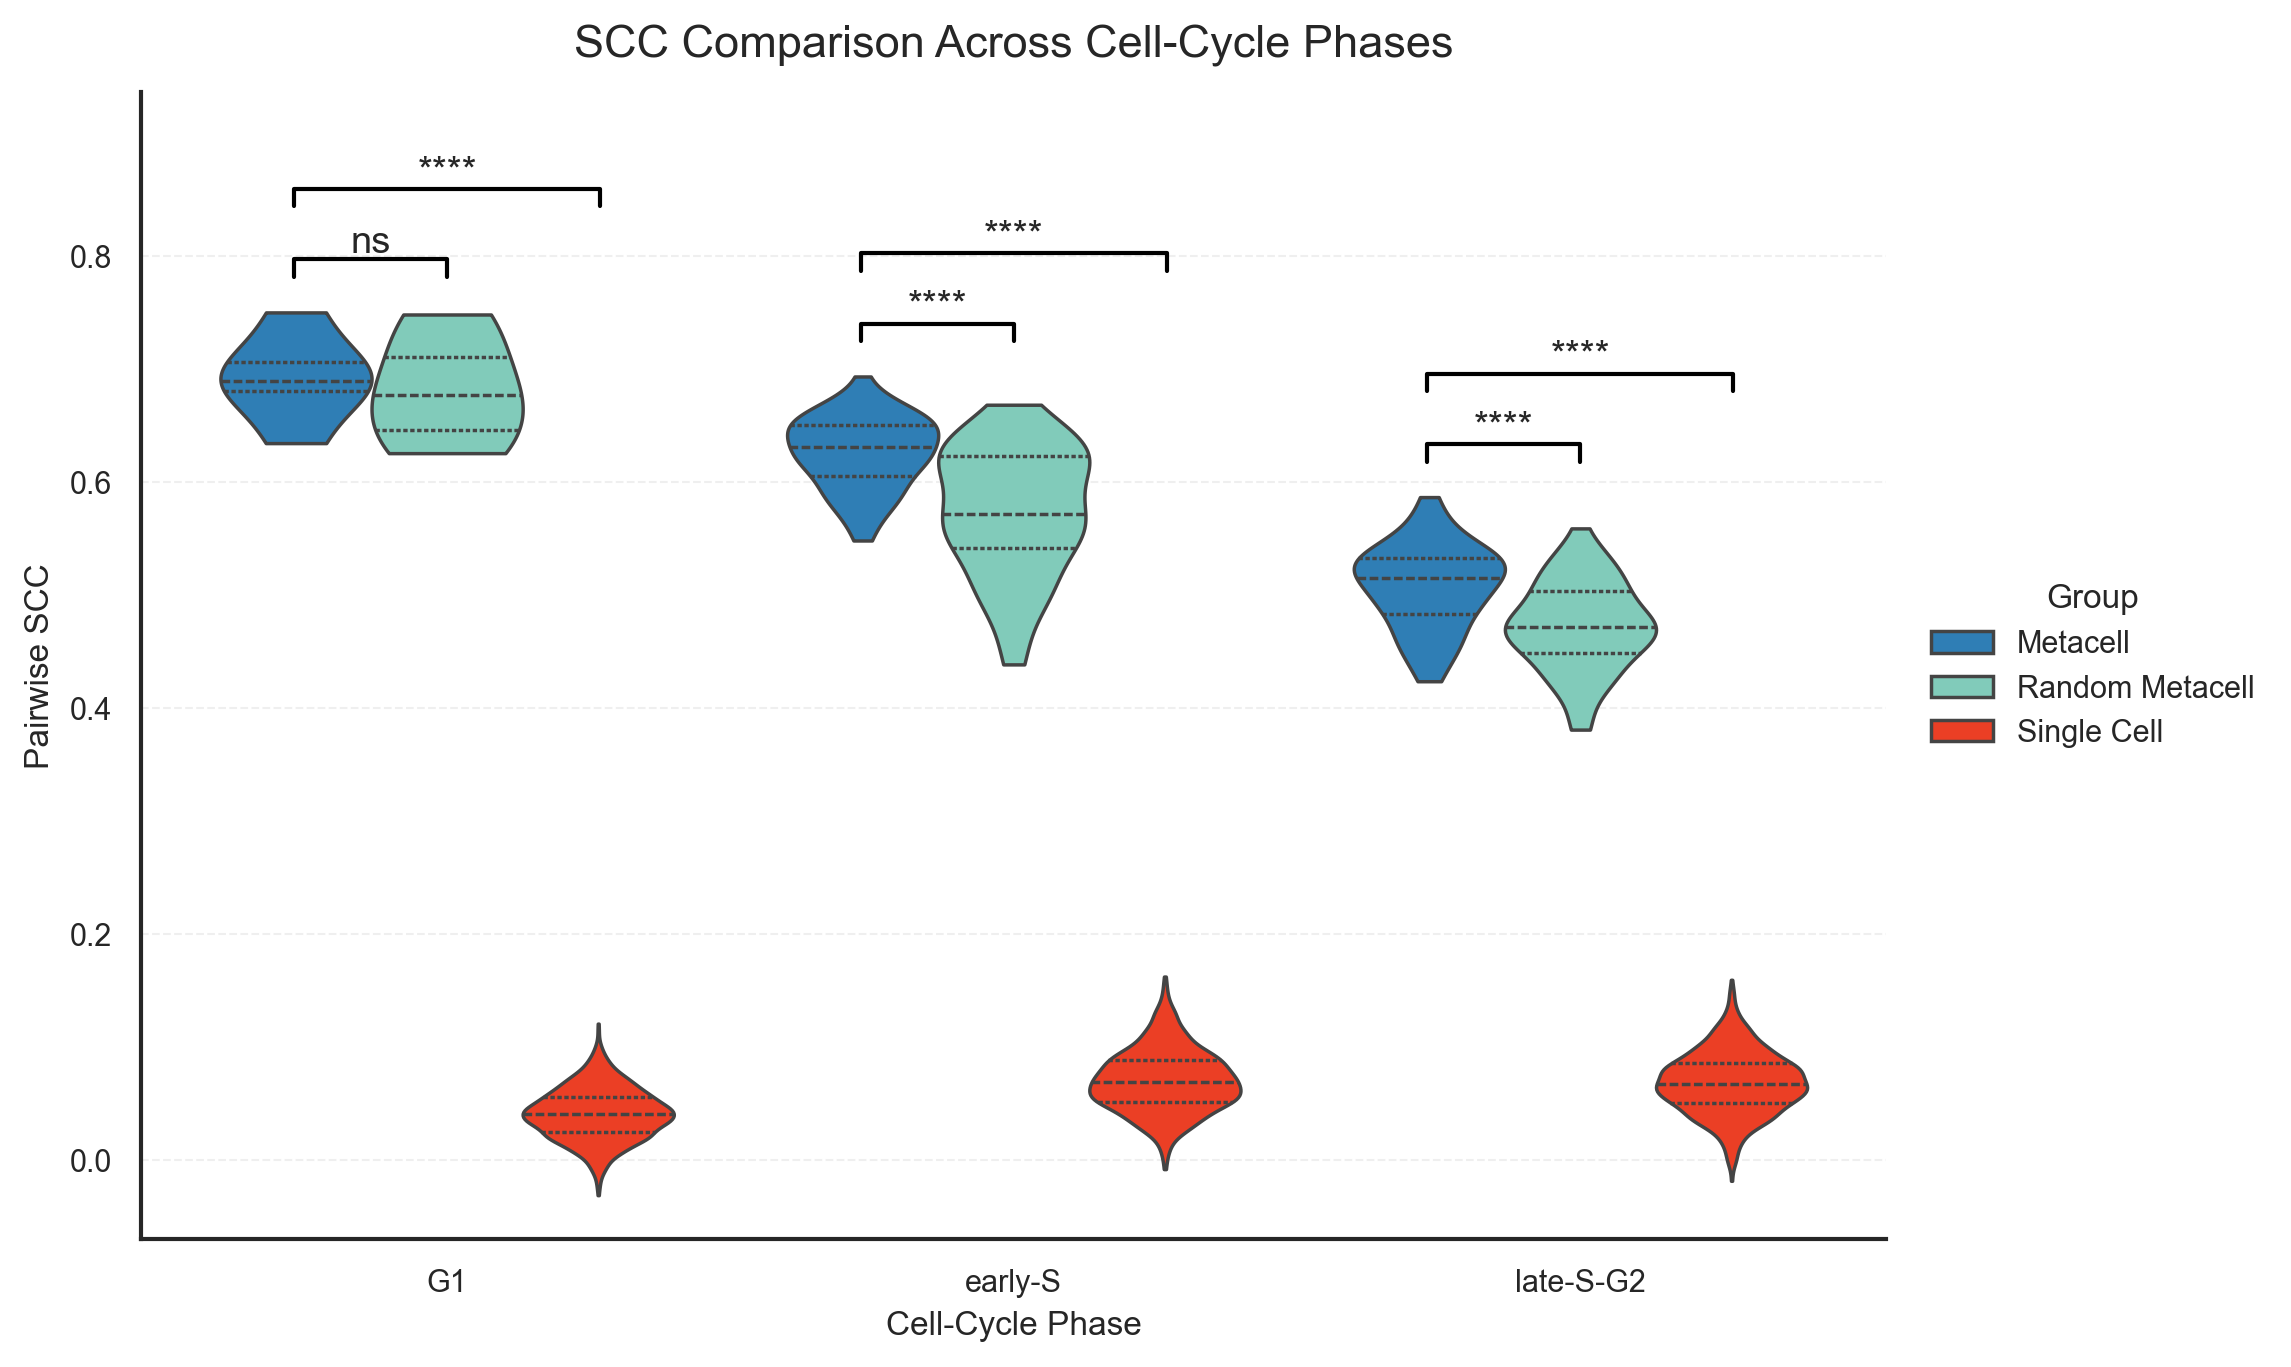

In [ ]:
# 仅重绘图：去掉叠加 boxplot，避免视觉上出现“多层 violin”
# 依赖上一个主单元已经生成的 df
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def p_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_sig_bar(ax, x1, x2, y, h, text, lw=1.2):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], c='black', lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=11)


if 'df' not in globals() or df.empty:
    raise ValueError("df 不存在或为空，请先运行主分析单元生成 df。")

sns.set_theme(
    style="white",
    context="paper",
    rc={
        "axes.linewidth": 1.2,
        "font.size": 11,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
    },
)

cycle_order = ['G1', 'early-S', 'late-S-G2']
type_order = ["Metacell", "Random Metacell", "Single Cell"]
palette = {
    "Metacell": "#2C7FB8",
    "Random Metacell": "#7FCDBB",
    "Single Cell": "#F03B20",
}

fig, ax = plt.subplots(figsize=(9.3, 5.6), dpi=250)

sns.violinplot(
    data=df,
    x='CellCycle',
    y='Correlation',
    hue='Type',
    order=cycle_order,
    hue_order=type_order,
    palette=palette,
    inner='quartile',
    cut=0,
    linewidth=1.0,
    saturation=0.95,
    density_norm='width',
    ax=ax,
)

# 图例顺序固定
handles, labels = ax.get_legend_handles_labels()
uniq = {}
for h, l in zip(handles, labels):
    if l not in uniq and l in type_order:
        uniq[l] = h
ax.legend(
    [uniq[t] for t in type_order if t in uniq],
    [t for t in type_order if t in uniq],
    title="Group",
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.01, 0.5),
)

# 组内假设检验：Metacell vs Random, Metacell vs Single
sig_rows = []
all_y = df['Correlation'].to_numpy()
y_min = float(np.nanmin(all_y))
y_max = float(np.nanmax(all_y))
y_range = max(1e-6, y_max - y_min)

for i, cyc in enumerate(cycle_order):
    dcyc = df[df['CellCycle'] == cyc]
    g_mc = dcyc[dcyc['Type'] == 'Metacell']['Correlation'].to_numpy()
    g_rd = dcyc[dcyc['Type'] == 'Random Metacell']['Correlation'].to_numpy()
    g_sc = dcyc[dcyc['Type'] == 'Single Cell']['Correlation'].to_numpy()

    if len(g_mc) > 0 and len(g_rd) > 0:
        _, p_mc_rd = mannwhitneyu(g_mc, g_rd, alternative='two-sided')
        s1 = p_to_stars(p_mc_rd)
        sig_rows.append({'CellCycle': cyc, 'Comparison': 'Metacell vs Random', 'p': p_mc_rd, 'Stars': s1})
    else:
        s1 = 'na'

    if len(g_mc) > 0 and len(g_sc) > 0:
        _, p_mc_sc = mannwhitneyu(g_mc, g_sc, alternative='two-sided')
        s2 = p_to_stars(p_mc_sc)
        sig_rows.append({'CellCycle': cyc, 'Comparison': 'Metacell vs Single', 'p': p_mc_sc, 'Stars': s2})
    else:
        s2 = 'na'

    cyc_max = float(np.nanmax(dcyc['Correlation'])) if len(dcyc) else y_max
    base_y = cyc_max + 0.04 * y_range
    h = 0.02 * y_range

    # 3个 hue 的偏移近似
    x_mc = i - 0.27
    x_rd = i
    x_sc = i + 0.27

    if s1 != 'na':
        add_sig_bar(ax, x_mc, x_rd, base_y, h, s1)
    if s2 != 'na':
        add_sig_bar(ax, x_mc, x_sc, base_y + 0.08 * y_range, h, s2)

sig_df = pd.DataFrame(sig_rows)
print("\n--- 组内显著性检验（Mann-Whitney U）---")
print(sig_df)

ax.set_title("SCC Comparison Across Cell-Cycle Phases", fontsize=13, pad=10)
ax.set_xlabel("Cell-Cycle Phase")
ax.set_ylabel("Pairwise SCC")
ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.30)
ax.set_ylim(y_min - 0.05 * y_range, y_max + 0.25 * y_range)

sns.despine(ax=ax, top=True, right=True)
plt.tight_layout()
plt.show()